In [24]:
import numpy as np 
import torch
from torch import nn

import matplotlib.pyplot as plt

In [25]:
def compute_magnetization(pd, t1, t2, flip_angle, te):
    m = 0.05 * torch.abs(pd * np.sin(flip_angle) / ((t1/t2+1) - np.cos(flip_angle) * (t1/t2-1)) * torch.exp(-te/t2))
    return m

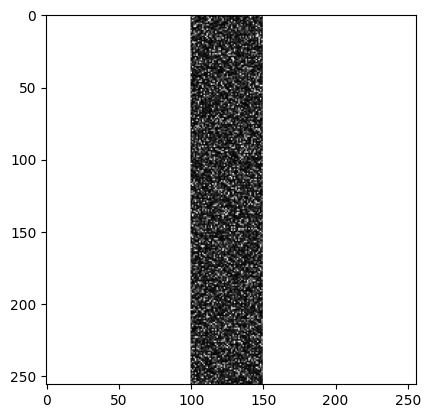

In [26]:
t1 = torch.rand((256,256)) * 10000
t2 = torch.zeros((256,256))
t2[:, 100:150] = 100

pd = torch.zeros((256,256))
pd[:, 100:150] = 10


flip_angle = 0.5
te = 10

m = compute_magnetization(pd, t1, t2, flip_angle, te)
plt.imshow(m.cpu().numpy(), cmap='gray')

In [33]:
class offsetNet(nn.Module):
    def __init__(self, target_size=(384,384)):
        super(offsetNet, self).__init__()
        self.offsets = nn.Parameter(torch.zeros(1, 3, target_size[0], target_size[1])) # Creats trainable paramters directly
        self.scale_param = nn.Parameter(torch.zeros(1))

    def forward(self):
        return self.offsets, torch.tanh(self.scale_param)    

In [34]:
mymodel = offsetNet()
mymodel()

(Parameter containing:
 tensor([[[[0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           ...,
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.]],
 
          [[0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           ...,
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.]],
 
          [[0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           ...,
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.]]]], requires_grad=True),
 tensor([0.], grad_fn=<TanhBackward0>))